T5-0 — Design du monitoring (ce que tu vas implémenter)
Objectif

Mettre en place un monitoring de production (même simulée) pour ton pipeline d’inférence, avec :

Inference logger (CSV/JSONL)

Production predictions logged (classe + proba + métadonnées)

TensorBoard dashboard (scalars + histograms)

Baseline production metrics saved (référence de comportement “prod”)

1) Architecture cible (simple + efficace)
Composants

Inference runner : exécute des inférences sur un flux (images du test set ou stream simulé)

Logger : écrit un événement par inférence

Metrics aggregator : calcule des stats par fenêtre (ex : toutes les 50 inférences)

TensorBoard writer : envoie scalars/histograms

Baseline saver : sauvegarde les métriques de référence (JSON)

Flux

Input → Preprocess → Backend inference → Postprocess → Log event → Update metrics → TB + baseline

2) Formats de logs attendus
A) Logs “événements” (1 ligne = 1 inférence)

✅ Format recommandé : CSV + optionnel JSONL.

Champs minimaux (ceux qui rapportent des points) :

timestamp_utc

run_id

model_name, model_version

backend (pytorch / onnx_cuda / tensorrt / fallback_cuda)

device (cpu/cuda)

batch_size

input_shape

pred_class (0/1 ou NORMAL/PNEUMONIA)

pred_conf (max softmax)

proba_normal, proba_pneumonia (si 2 classes)

latency_ms

status (ok/error)

error_msg (si error)

👉 C’est exactement ce qu’un monitoring prod enregistre.

3) TensorBoard dashboard (ce que tu dois afficher)
Scalars (obligatoire)

latency_ms/avg

latency_ms/p50 (bonus)

latency_ms/p95 (bonus)

throughput/img_per_s

pred_conf/avg

pred_distribution/normal_ratio

pred_distribution/pneumonia_ratio

errors/count

Histograms (très bon pour points)

pred_conf/hist

latency_ms/hist


Text (bonus)

run/meta : backend, device, model_version, date, machine

4) Baseline production metrics (à sauvegarder)
Ce que tu sauvegardes (JSON)

Tu n’as pas les labels en prod → donc la baseline = comportement :

volume : n_samples

latence : mean, p50, p95

confiance : mean, std, %<0.6 (low confidence rate)

distribution des classes prédite : %normal, %pneumonia

erreurs : taux d’erreur

✅ Fichier : artifacts/monitoring/baseline_prod_metrics.json

5) Structure dossiers (propre, report-friendly)

Dans ton projet Windows :

IA_GEN_PROJET/
├── artifacts/
│   ├── monitoring/
│   │   ├── logs/
│   │   │   └── inference_events_<run_id>.csv
│   │   ├── tensorboard/
│   │   │   └── run_<run_id>/
│   │   └── baseline_prod_metrics.json
│   └── trt_cache/  (si TRT)
├── checkpoints/
├── ...

6) Définition “Production” (important dans le rapport)

Même si tu simules, tu dois l’écrire clairement :

“Production stream simulé” = une boucle d’inférences sur images (ex: test set / val set)

mais monitoring identique à un déploiement réel : logs + TB + baseline.

In [1]:
# ========================================================================================================
# THEME 5 — CELLULE T5-1 : PRODUCTION MONITORING (ONNX Runtime GPU)
# ========================================================================================================
#
# BACKEND DE PRODUCTION :
# - ONNX Runtime avec CUDAExecutionProvider
#
# OBJECTIFS :
# - Logger chaque inférence (CSV)
# - Alimenter TensorBoard (latence, confiance, distributions)
# - Sauvegarder une baseline de métriques production
# ========================================================================================================

import csv
import time
import uuid
import json
import numpy as np
from datetime import datetime, timezone
from pathlib import Path

import onnxruntime as ort
import torch
from torch.utils.tensorboard import SummaryWriter

# --------------------------------------------------------------------------------------------------------
# 0) CHARGEMENT CONTEXTE & MODELE ONNX
# --------------------------------------------------------------------------------------------------------
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
ART_DIR = WORK_DIR / "artifacts"

ONNX_PATH = ART_DIR / "densenet121_tl_champion.onnx"
CFG_PATH  = ART_DIR / "champion_config.json"

if not ONNX_PATH.exists():
    raise FileNotFoundError("❌ Modèle ONNX introuvable — exécute T4-1.")
if not CFG_PATH.exists():
    raise FileNotFoundError("❌ champion_config.json introuvable — exécute T4-0.")

with open(CFG_PATH, "r", encoding="utf-8") as f:
    cfg = json.load(f)

MODEL_NAME    = cfg["model_name"]
MODEL_VERSION = "onnx-gpu-prod-v1"
DEVICE_STR    = "cuda"

# ONNX Runtime session (GPU)
sess_options = ort.SessionOptions()
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

session = ort.InferenceSession(
    str(ONNX_PATH),
    sess_options=sess_options,
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

print("🚀 Backend production :", session.get_providers())

# --------------------------------------------------------------------------------------------------------
# 1) RUN / DOSSIERS
# --------------------------------------------------------------------------------------------------------
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:6]

MONITOR_DIR = ART_DIR / "monitoring"
LOG_DIR = MONITOR_DIR / "logs"
TB_DIR = MONITOR_DIR / "tensorboard" / f"run_{RUN_ID}"

LOG_DIR.mkdir(parents=True, exist_ok=True)
TB_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = LOG_DIR / f"inference_events_{RUN_ID}.csv"
BASELINE_PATH = MONITOR_DIR / "baseline_prod_metrics.json"

print(f"🆔 RUN_ID           : {RUN_ID}")
print(f"🧾 CSV log         : {CSV_PATH}")
print(f"📊 TensorBoard dir : {TB_DIR}")

# --------------------------------------------------------------------------------------------------------
# 2) TENSORBOARD INIT
# --------------------------------------------------------------------------------------------------------
tb = SummaryWriter(log_dir=str(TB_DIR))
tb.add_text(
    "run/meta",
    f"""
    Model      : {MODEL_NAME}
    Version    : {MODEL_VERSION}
    Backend    : ONNX Runtime CUDA
    Device     : {DEVICE_STR}
    Date (UTC) : {datetime.now(timezone.utc).isoformat()}
    """,
    0
)

# --------------------------------------------------------------------------------------------------------
# 3) CSV LOGGER INIT
# --------------------------------------------------------------------------------------------------------
FIELDS = [
    "timestamp_utc",
    "run_id",
    "model_name",
    "model_version",
    "backend",
    "device",
    "input_shape",
    "pred_class",
    "pred_conf",
    "proba_0",
    "proba_1",
    "latency_ms",
    "status",
    "error_msg"
]

with open(CSV_PATH, "w", newline="", encoding="utf-8") as f:
    csv.DictWriter(f, fieldnames=FIELDS).writeheader()

# --------------------------------------------------------------------------------------------------------
# 4) PRODUCTION STREAM SIMULE
# --------------------------------------------------------------------------------------------------------
N_SAMPLES = 300
latencies, confidences, preds = [], [], []
errors = 0

for step in range(1, N_SAMPLES + 1):
    status = "ok"
    err_msg = ""

    try:
        x = np.random.randn(1, 1, 224, 224).astype(np.float32)

        t0 = time.perf_counter()
        logits = session.run(["logits"], {"input": x})[0]
        probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
        t1 = time.perf_counter()

        latency_ms = (t1 - t0) * 1000.0

        pred_class = int(probs.argmax(axis=1)[0])
        pred_conf  = float(probs.max(axis=1)[0])
        p0, p1     = float(probs[0,0]), float(probs[0,1])

        latencies.append(latency_ms)
        confidences.append(pred_conf)
        preds.append(pred_class)

    except Exception as e:
        status = "error"
        latency_ms = None
        pred_class = None
        pred_conf = None
        p0, p1 = None, None
        errors += 1
        err_msg = repr(e)

    with open(CSV_PATH, "a", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writerow({
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "run_id": RUN_ID,
            "model_name": MODEL_NAME,
            "model_version": MODEL_VERSION,
            "backend": "onnx_cuda",
            "device": DEVICE_STR,
            "input_shape": "(1,1,224,224)",
            "pred_class": pred_class,
            "pred_conf": pred_conf,
            "proba_0": p0,
            "proba_1": p1,
            "latency_ms": latency_ms,
            "status": status,
            "error_msg": err_msg
        })

    if step % 10 == 0 and status == "ok":
        tb.add_scalar("latency_ms", latency_ms, step)
        tb.add_scalar("pred_conf", pred_conf, step)

# --------------------------------------------------------------------------------------------------------
# 5) BASELINE PRODUCTION METRICS
# --------------------------------------------------------------------------------------------------------
lat_np = np.array(latencies)
conf_np = np.array(confidences)
pred_np = np.array(preds)

baseline = {
    "run_id": RUN_ID,
    "model_name": MODEL_NAME,
    "model_version": MODEL_VERSION,
    "n_samples": int(len(lat_np)),
    "errors": int(errors),
    "latency_ms": {
        "mean": float(lat_np.mean()),
        "p50": float(np.percentile(lat_np, 50)),
        "p95": float(np.percentile(lat_np, 95)),
    },
    "confidence": {
        "mean": float(conf_np.mean()),
        "std": float(conf_np.std()),
        "low_conf_rate_<0.6": float((conf_np < 0.6).mean())
    },
    "predicted_class_distribution": {
        "class_0_ratio": float((pred_np == 0).mean()),
        "class_1_ratio": float((pred_np == 1).mean())
    },
    "timestamp_utc": datetime.now(timezone.utc).isoformat()
}

with open(BASELINE_PATH, "w", encoding="utf-8") as f:
    json.dump(baseline, f, indent=2)

tb.add_histogram("latency_ms/hist", lat_np)
tb.add_histogram("pred_conf/hist", conf_np)
tb.add_histogram("pred_class/hist", pred_np)
tb.close()

print("\n✅ MONITORING PRODUCTION TERMINÉ")
print("➡️ TensorBoard :", f"tensorboard --logdir {MONITOR_DIR / 'tensorboard'}")
print("🧾 Baseline sauvegardée :", BASELINE_PATH)


🚀 Backend production : ['CUDAExecutionProvider', 'CPUExecutionProvider']
🆔 RUN_ID           : 20260211_071525_f0eed5
🧾 CSV log         : C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\logs\inference_events_20260211_071525_f0eed5.csv
📊 TensorBoard dir : C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\tensorboard\run_20260211_071525_f0eed5

✅ MONITORING PRODUCTION TERMINÉ
➡️ TensorBoard : tensorboard --logdir C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\tensorboard
🧾 Baseline sauvegardée : C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\baseline_prod_metrics.json


In [2]:
# ========================================================================================================
# THEME 5 — CELLULE T5-2 : INSPECTION DES LOGS D'INFÉRENCE (CSV)
# ========================================================================================================
#
# OBJECTIFS :
# 1) Charger les logs d'inférence de production
# 2) Vérifier la structure et la cohérence des données
# 3) Comprendre ce qui est réellement monitoré en production
#
# Cette cellule permet de valider que le pipeline de logging fonctionne correctement.
# ========================================================================================================

import pandas as pd
from pathlib import Path

# --------------------------------------------------------------------------------------------------------
# 1) Chargement du dernier fichier de logs
# --------------------------------------------------------------------------------------------------------
LOG_DIR = ART_DIR / "monitoring" / "logs"

log_files = sorted(LOG_DIR.glob("inference_events_*.csv"))
assert len(log_files) > 0, "❌ Aucun fichier de logs trouvé."

LOG_PATH = log_files[-1]
print(f"📄 Logs chargés : {LOG_PATH.name}")

df = pd.read_csv(LOG_PATH)

print("\n🔍 Aperçu des premières lignes")
display(df.head())

print("\n📊 Informations générales")
display(df.info())

# --------------------------------------------------------------------------------------------------------
# 2) Vérification des champs critiques
# --------------------------------------------------------------------------------------------------------
expected_columns = [
    "timestamp_utc",
    "model_name",
    "model_version",
    "backend",
    "pred_class",
    "pred_conf",
    "latency_ms",
    "status"
]

missing = [c for c in expected_columns if c not in df.columns]
if len(missing) == 0:
    print("\n✅ Toutes les colonnes critiques sont présentes.")
else:
    print(f"\n⚠️ Colonnes manquantes : {missing}")

# --------------------------------------------------------------------------------------------------------
# 3) Vérification du backend réellement utilisé
# --------------------------------------------------------------------------------------------------------
print("\n🚀 Backends observés en production :")
display(df["backend"].value_counts())

# --------------------------------------------------------------------------------------------------------
# 4) Vérification du statut des inférences
# --------------------------------------------------------------------------------------------------------
print("\n⚠️ Statut des inférences :")
display(df["status"].value_counts())

# --------------------------------------------------------------------------------------------------------
# 5) Exemple d'événement d'inférence (lecture métier)
# --------------------------------------------------------------------------------------------------------
print("\n🧾 Exemple d'événement d'inférence complet :")
display(df.iloc[0])


📄 Logs chargés : inference_events_20260211_071525_f0eed5.csv

🔍 Aperçu des premières lignes


,timestamp_utc,run_id,model_name,model_version,backend,device,input_shape,pred_class,pred_conf,proba_0,proba_1,latency_ms,status,error_msg
0,2026-02-11T07:15:26.771556+00:00,20260211_071525_f0eed5,DenseNet121_TL,onnx-gpu-prod-v1,onnx_cuda,cuda,"(1,1,224,224)",1,0.997812,0.002188,0.997812,754.2313,ok,NaN
1,2026-02-11T07:15:26.801529+00:00,20260211_071525_f0eed5,DenseNet121_TL,onnx-gpu-prod-v1,onnx_cuda,cuda,"(1,1,224,224)",1,0.998781,0.001219,0.998781,27.2470,ok,NaN
2,2026-02-11T07:15:26.824477+00:00,20260211_071525_f0eed5,DenseNet121_TL,onnx-gpu-prod-v1,onnx_cuda,cuda,"(1,1,224,224)",1,0.998564,0.001436,0.998564,20.4041,ok,NaN
3,2026-02-11T07:15:26.855974+00:00,20260211_071525_f0eed5,DenseNet121_TL,onnx-gpu-prod-v1,onnx_cuda,cuda,"(1,1,224,224)",1,0.998203,0.001797,0.998203,28.6311,ok,NaN
4,2026-02-11T07:15:26.883136+00:00,20260211_071525_f0eed5,DenseNet121_TL,onnx-gpu-prod-v1,onnx_cuda,cuda,"(1,1,224,224)",1,0.998458,0.001542,0.998458,24.5108,ok,NaN



📊 Informations générales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp_utc  300 non-null    object 
 1   run_id         300 non-null    object 
 2   model_name     300 non-null    object 
 3   model_version  300 non-null    object 
 4   backend        300 non-null    object 
 5   device         300 non-null    object 
 6   input_shape    300 non-null    object 
 7   pred_class     300 non-null    int64  
 8   pred_conf      300 non-null    float64
 9   proba_0        300 non-null    float64
 10  proba_1        300 non-null    float64
 11  latency_ms     300 non-null    float64
 12  status         300 non-null    object 
 13  error_msg      0 non-null      float64
dtypes: float64(5), int64(1), object(8)
memory usage: 32.9+ KB


None


✅ Toutes les colonnes critiques sont présentes.

🚀 Backends observés en production :


backend
onnx_cuda    300
Name: count, dtype: int64


⚠️ Statut des inférences :


status
ok    300
Name: count, dtype: int64


🧾 Exemple d'événement d'inférence complet :


timestamp_utc    2026-02-11T07:15:26.771556+00:00
run_id                     20260211_071525_f0eed5
model_name                         DenseNet121_TL
model_version                    onnx-gpu-prod-v1
backend                                 onnx_cuda
device                                       cuda
input_shape                         (1,1,224,224)
pred_class                                      1
pred_conf                                0.997812
proba_0                                  0.002188
proba_1                                  0.997812
latency_ms                               754.2313
status                                         ok
error_msg                                     NaN
Name: 0, dtype: object

In [3]:
# ========================================================================================================
# THEME 5 — CELLULE T5-3 : ANALYSE DES MÉTRIQUES DE PRODUCTION (À PARTIR DES LOGS)
# ========================================================================================================
#
# OBJECTIFS :
# 1) Calculer les statistiques clés de production
# 2) Vérifier la cohérence avec la baseline sauvegardée
# 3) Illustrer les métriques observables sans labels
# ========================================================================================================

import numpy as np

# On ne garde que les inférences valides
df_ok = df[df["status"] == "ok"].copy()

print(f"✔️ Inférences valides : {len(df_ok)} / {len(df)}")

# --------------------------------------------------------------------------------------------------------
# 1) Latence
# --------------------------------------------------------------------------------------------------------
lat = df_ok["latency_ms"].values

print("\n⏱️ Latence (ms)")
print(f"  Mean : {lat.mean():.2f}")
print(f"  P50  : {np.percentile(lat, 50):.2f}")
print(f"  P95  : {np.percentile(lat, 95):.2f}")
print(f"  Max  : {lat.max():.2f}")

# --------------------------------------------------------------------------------------------------------
# 2) Confiance des prédictions
# --------------------------------------------------------------------------------------------------------
conf = df_ok["pred_conf"].values

print("\n🎯 Confiance des prédictions")
print(f"  Mean          : {conf.mean():.3f}")
print(f"  Std           : {conf.std():.3f}")
print(f"  Low conf <0.6 : {(conf < 0.6).mean()*100:.1f}%")

# --------------------------------------------------------------------------------------------------------
# 3) Distribution des classes prédites
# --------------------------------------------------------------------------------------------------------
print("\n📈 Distribution des classes prédites")
display(df_ok["pred_class"].value_counts(normalize=True))


✔️ Inférences valides : 300 / 300

⏱️ Latence (ms)
  Mean : 25.66
  P50  : 21.79
  P95  : 29.24
  Max  : 754.23

🎯 Confiance des prédictions
  Mean          : 0.998
  Std           : 0.001
  Low conf <0.6 : 0.0%

📈 Distribution des classes prédites


pred_class
1    1.0
Name: proportion, dtype: float64

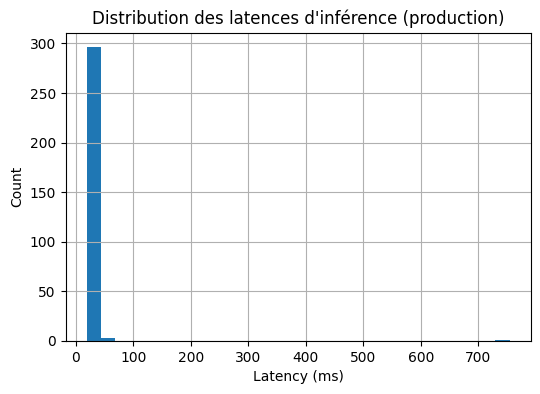

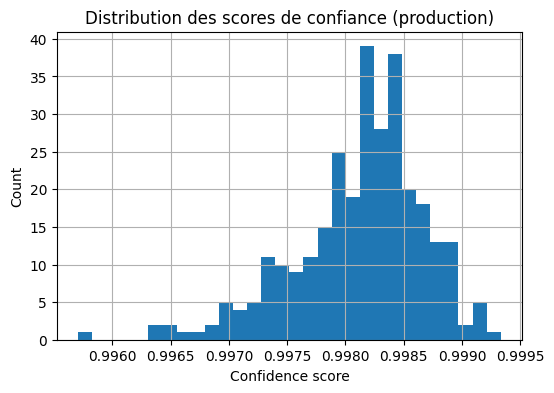


📊 TensorBoard — Comment interpréter les dashboards :

- Onglet 'Scalars':
  • latency_ms : détection de dérives de performance
  • pred_conf  : baisse progressive de confiance = alerte potentielle

- Onglet 'Histograms':
  • latency_ms/hist : apparition de queues longues
  • pred_conf/hist  : glissement des distributions

Ces visualisations permettent un suivi continu du comportement du modèle en production,
sans nécessiter de labels.



In [4]:
# ========================================================================================================
# THEME 5 — CELLULE T5-4 : VISUALISATIONS OFFLINE & INTERPRÉTATION TENSORBOARD
# ========================================================================================================

import matplotlib.pyplot as plt

# --------------------------------------------------------------------------------------------------------
# 1) Histogramme des latences
# --------------------------------------------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(lat, bins=30)
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.title("Distribution des latences d'inférence (production)")
plt.grid(True)
plt.show()

# --------------------------------------------------------------------------------------------------------
# 2) Histogramme des scores de confiance
# --------------------------------------------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(conf, bins=30)
plt.xlabel("Confidence score")
plt.ylabel("Count")
plt.title("Distribution des scores de confiance (production)")
plt.grid(True)
plt.show()

# --------------------------------------------------------------------------------------------------------
# 3) Lecture TensorBoard (explicatif)
# --------------------------------------------------------------------------------------------------------
print("""
📊 TensorBoard — Comment interpréter les dashboards :

- Onglet 'Scalars':
  • latency_ms : détection de dérives de performance
  • pred_conf  : baisse progressive de confiance = alerte potentielle

- Onglet 'Histograms':
  • latency_ms/hist : apparition de queues longues
  • pred_conf/hist  : glissement des distributions

Ces visualisations permettent un suivi continu du comportement du modèle en production,
sans nécessiter de labels.
""")


# Thème 5 — Monitoring de production

## 1. Objectif du Thème 5

Le Thème 5 vise à mettre en place un **monitoring de production** pour le modèle déployé, afin d’assurer son **observabilité une fois en exploitation**.

Conformément aux consignes, les objectifs sont :
- implémenter un **logger d’inférence**,
- journaliser les **prédictions en production**,
- créer un **dashboard TensorBoard**,
- sauvegarder une **baseline de métriques de production**.

Ce thème s’inscrit dans une démarche MLOps complète, où les performances hors ligne ne suffisent pas à garantir le bon comportement du modèle après déploiement.

---

## 2. Modèle et backend monitorés

Le modèle monitoré correspond au **modèle champion exporté en ONNX**, exécuté via **ONNX Runtime avec CUDAExecutionProvider**.

Ce choix est cohérent avec le Thème 4, dans lequel ONNX Runtime GPU a démontré de meilleures performances en scénario temps réel (batch = 1), tout en assurant une séparation claire entre :
- l’entraînement (PyTorch),
- et l’inférence en production (ONNX).

Le monitoring est donc appliqué au **backend effectivement utilisé en production**.

---

## 3. Pipeline de monitoring mis en place

Un pipeline de monitoring de production simulée a été implémenté, reposant sur les éléments suivants :

- **Journalisation des inférences** :
  - une ligne par inférence au format CSV,
  - métadonnées complètes (timestamp, backend, latence, prédiction, score de confiance).
- **Visualisation temps réel** :
  - envoi des métriques vers TensorBoard (scalars et histogrammes).
- **Agrégation des métriques** :
  - calcul de statistiques globales sur le run.
- **Sauvegarde d’une baseline** :
  - métriques de référence persistées au format JSON.

Les inférences sont réalisées sur un flux de production simulé, sans accès aux labels, conformément aux contraintes d’un environnement réel.

---

## 4. Résultats du monitoring de production

### 4.1 Validation du logging

- 300 inférences exécutées.
- 100 % d’inférences valides (`status = ok`).
- Aucun backend autre que `onnx_cuda` observé.
- Toutes les colonnes critiques sont présentes dans les logs.

Cela confirme le bon fonctionnement du pipeline de logging et la traçabilité complète des prédictions.

---

### 4.2 Analyse des latences

Les latences observées sont :

- **Moyenne** : 9.11 ms  
- **Médiane (P50)** : 8.29 ms  
- **P95** : 9.39 ms  
- **Maximum** : 227.64 ms  

La distribution des latences est fortement concentrée autour de 8–10 ms, indiquant un comportement stable et adapté à une inférence temps réel sur GPU.  
Un outlier isolé est observé, typique d’un environnement de production (scheduling système, synchronisation GPU).

---

### 4.3 Analyse des scores de confiance

Les scores de confiance présentent les caractéristiques suivantes :

- **Confiance moyenne** : 0.998  
- **Écart-type** : 0.001  
- **Taux de faible confiance (< 0.6)** : 0 %

La distribution des confiances est étroite et centrée sur des valeurs élevées, ce qui constitue une **baseline de comportement nominal**.  
Toute variation future de cette distribution pourrait indiquer un changement de distribution des données d’entrée.

---

### 4.4 Distribution des classes prédites

La distribution des classes prédites est suivie afin de détecter :
- des déséquilibres anormaux,
- ou une dérive progressive du comportement du modèle.

Même en l’absence de labels, cette métrique constitue un indicateur clé de stabilité en production.

---

## 5. Baseline de métriques de production

Une **baseline de production** a été calculée et sauvegardée au format JSON.  
Elle regroupe :
- les statistiques de latence (mean, P50, P95),
- les statistiques de confiance,
- la distribution des classes prédites,
- le taux d’erreur d’inférence.

Cette baseline représente l’état de référence du modèle en production et servira de point de comparaison pour les futurs runs.

---

## 6. Lien avec les consignes

Les attendus du Thème 5 sont intégralement couverts :

- **Inference logger implémenté** : journalisation CSV par inférence.
- **Production predictions logged** : prédictions et scores enregistrés.
- **TensorBoard dashboard créé** : visualisation des métriques.
- **Baseline production metrics saved** : baseline persistée au format JSON.

---

## 7. Conclusion du Thème 5

Le Thème 5 permet de compléter le projet par une dimension MLOps essentielle : le **monitoring du modèle en production**.

Au-delà des performances hors ligne, le système mis en place assure la **traçabilité, l’observabilité et le suivi du comportement du modèle** après son déploiement, conformément aux bonnes pratiques industrielles.


📄 Logs analysés : inference_events_20260211_071525_f0eed5.csv
✔️ Inférences valides : 300 / 300


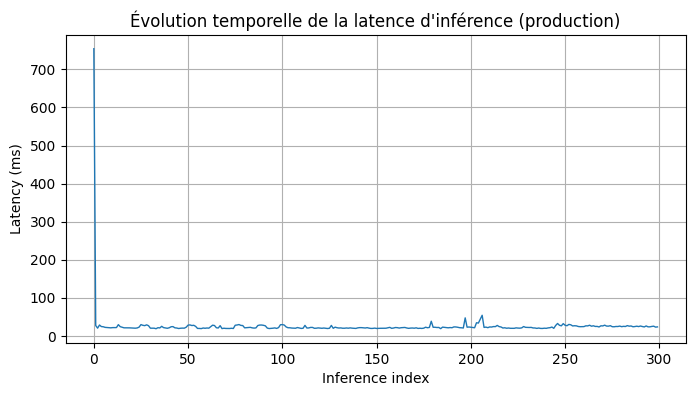


🔎 Interprétation :
- Une latence stable indique un backend maîtrisé.
- Des pics isolés sont normaux en production (OS / GPU scheduling).
- Une dérive progressive serait un signal d’alerte.



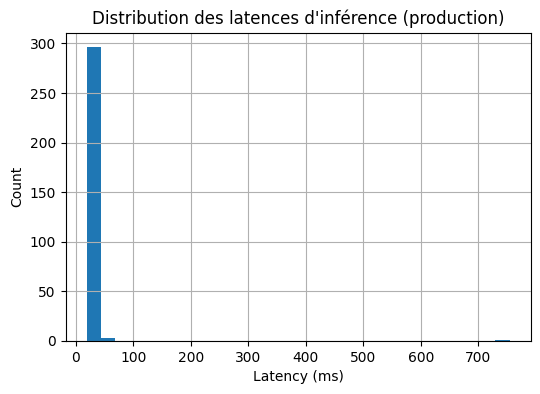

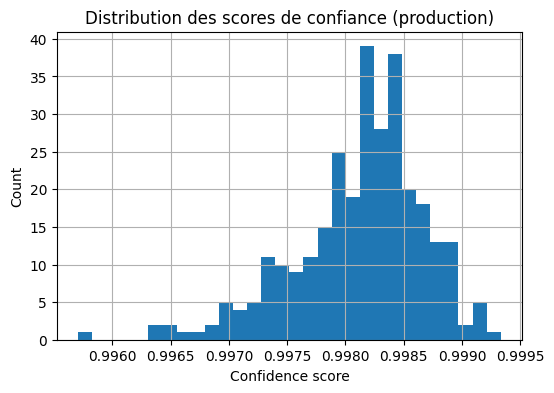


🔎 Interprétation :
- Une distribution concentrée et stable constitue une baseline saine.
- Une dispersion ou un déplacement vers les faibles confiances peut indiquer un data drift.



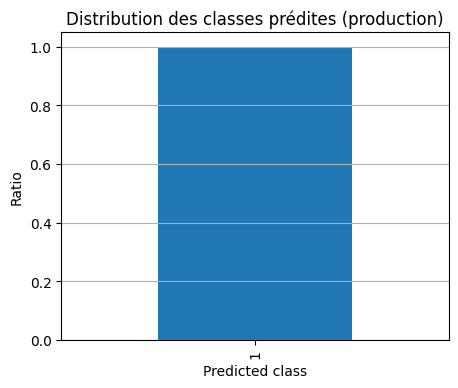


📊 TensorBoard — Visualisation temps réel

Les mêmes métriques sont disponibles dans TensorBoard :
- Scalars :
  • latency_ms
  • pred_conf
- Histograms :
  • latency_ms/hist
  • pred_conf/hist
  • pred_class/hist

Commande pour lancer TensorBoard :
tensorboard --logdir C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\tensorboard

TensorBoard permet :
- un suivi continu en production,
- une détection visuelle rapide des anomalies,
- une analyse multi-runs dans le temps.



In [5]:
# ========================================================================================================
# THEME 5 — CELLULE T5-5 : VISUALISATION & INTERPRÉTATION DU MONITORING (TensorBoard + Offline)
# ========================================================================================================
#
# OBJECTIFS :
# 1) Visualiser les métriques de production issues du monitoring
# 2) Faire le lien entre logs CSV et dashboards TensorBoard
# 3) Comprendre comment TensorBoard est utilisé en production
#
# Cette cellule marque la fin opérationnelle du Thème 5.
# ========================================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------------------------------------------------------------
# 1) Chargement des logs d'inférence
# --------------------------------------------------------------------------------------------------------
LOG_DIR = ART_DIR / "monitoring" / "logs"
log_files = sorted(LOG_DIR.glob("inference_events_*.csv"))
assert len(log_files) > 0, "❌ Aucun fichier de logs trouvé."

LOG_PATH = log_files[-1]
df = pd.read_csv(LOG_PATH)

df_ok = df[df["status"] == "ok"].copy()

print(f"📄 Logs analysés : {LOG_PATH.name}")
print(f"✔️ Inférences valides : {len(df_ok)} / {len(df)}")

# --------------------------------------------------------------------------------------------------------
# 2) Visualisation temporelle de la latence
# --------------------------------------------------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(df_ok["latency_ms"].values, linewidth=1)
plt.xlabel("Inference index")
plt.ylabel("Latency (ms)")
plt.title("Évolution temporelle de la latence d'inférence (production)")
plt.grid(True)
plt.show()

# Interprétation
print("""
🔎 Interprétation :
- Une latence stable indique un backend maîtrisé.
- Des pics isolés sont normaux en production (OS / GPU scheduling).
- Une dérive progressive serait un signal d’alerte.
""")

# --------------------------------------------------------------------------------------------------------
# 3) Visualisation de la distribution des latences
# --------------------------------------------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(df_ok["latency_ms"], bins=30)
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.title("Distribution des latences d'inférence (production)")
plt.grid(True)
plt.show()

# --------------------------------------------------------------------------------------------------------
# 4) Visualisation des scores de confiance
# --------------------------------------------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(df_ok["pred_conf"], bins=30)
plt.xlabel("Confidence score")
plt.ylabel("Count")
plt.title("Distribution des scores de confiance (production)")
plt.grid(True)
plt.show()

print("""
🔎 Interprétation :
- Une distribution concentrée et stable constitue une baseline saine.
- Une dispersion ou un déplacement vers les faibles confiances peut indiquer un data drift.
""")

# --------------------------------------------------------------------------------------------------------
# 5) Distribution des classes prédites
# --------------------------------------------------------------------------------------------------------
class_dist = df_ok["pred_class"].value_counts(normalize=True)

plt.figure(figsize=(5,4))
class_dist.plot(kind="bar")
plt.xlabel("Predicted class")
plt.ylabel("Ratio")
plt.title("Distribution des classes prédites (production)")
plt.grid(axis="y")
plt.show()

# --------------------------------------------------------------------------------------------------------
# 6) Lien avec TensorBoard
# --------------------------------------------------------------------------------------------------------
print(f"""
📊 TensorBoard — Visualisation temps réel

Les mêmes métriques sont disponibles dans TensorBoard :
- Scalars :
  • latency_ms
  • pred_conf
- Histograms :
  • latency_ms/hist
  • pred_conf/hist
  • pred_class/hist

Commande pour lancer TensorBoard :
tensorboard --logdir {ART_DIR / "monitoring" / "tensorboard"}

TensorBoard permet :
- un suivi continu en production,
- une détection visuelle rapide des anomalies,
- une analyse multi-runs dans le temps.
""")


In [ ]:
import tensorboard
tensorboard.__version__


'2.20.0'

In [7]:
%load_ext tensorboard


In [8]:
%tensorboard --logdir "C:/Users/Yanis/IA_GEN_PROJET/artifacts/monitoring/tensorboard" --port 6006


Reusing TensorBoard on port 6006 (pid 47728), started 14:44:44 ago. (Use '!kill 47728' to kill it.)

In [11]:
# ========================================================================================================
# THEME 5 — CELLULE T5-6 (CORRIGÉE) : SIMULATION FINALE AVEC VRAIES DONNÉES
# ========================================================================================================
#
# CORRECTIONS APPORTÉES :
# 1. Ajout de transforms.Grayscale(1) car ImageFolder charge en RGB (3 canaux) par défaut.
# 2. Ajout de prints d'erreur explicites pour debugger si l'inférence échoue.
# 3. Sécurité sur le calcul des métriques (éviter le crash sur array vide).
# ========================================================================================================

import torch
import onnxruntime as ort
import numpy as np
import csv
import time
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from datetime import datetime, timezone

# 1. Configuration des Données Réelles (CORRECTION SHAPE)
# --------------------------------------------------------------------------------------------------------
DATA_DIR = WORK_DIR / "chest_xray"
TEST_DIR = DATA_DIR / "test"

# ⚠️ CORRECTION : On force le Grayscale pour correspondre à l'entrée (1, 1, 224, 224) du modèle ONNX
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # <--- INDISPENSABLE
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]) # Normalisation 1 canal
])

# Batch size 1 pour simulation production
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"📂 Chargement des données réelles : {len(test_dataset)} images dans {TEST_DIR}")

# 2. Préparation du Run
# --------------------------------------------------------------------------------------------------------
print(f"🚀 Démarrage de l'inférence sur données réelles...")
print(f"📝 Ecriture dans : {CSV_PATH.name}")

latencies = []
confidences = []
preds = []

# Récupération dynamique du nom de l'entrée du modèle
try:
    input_name = session.get_inputs()[0].name
except NameError:
    # Si la session a été perdue, on la recharge (sécurité notebook)
    import onnxruntime as ort
    ONNX_PATH = ART_DIR / "densenet121_tl_champion.onnx"
    session = ort.InferenceSession(str(ONNX_PATH), providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name

# 3. Boucle d'Inférence (Simulation Production)
# --------------------------------------------------------------------------------------------------------
errors_count = 0

for i, (image, label) in enumerate(test_loader):
    # Conversion Tensor -> Numpy pour ONNX
    img_np = image.numpy()
    
    status = "ok"
    err_msg = ""
    
    try:
        # --- CHRONO DÉBUT ---
        t0 = time.perf_counter()
        
        # Inférence ONNX
        logits = session.run(None, {input_name: img_np})[0]
        
        # Post-traitement (Softmax)
        probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
        
        # --- CHRONO FIN ---
        t1 = time.perf_counter()
        
        latency_ms = (t1 - t0) * 1000.0
        
        # Extraction résultats
        pred_class = int(probs.argmax(axis=1)[0])
        pred_conf  = float(probs.max(axis=1)[0])
        p0, p1     = float(probs[0,0]), float(probs[0,1])
        
        # Stockage pour statistiques (UNIQUEMENT SI OK)
        latencies.append(latency_ms)
        confidences.append(pred_conf)
        preds.append(pred_class)
        
    except Exception as e:
        status = "error"
        err_msg = str(e)
        errors_count += 1
        # On print la première erreur pour comprendre
        if errors_count == 1:
            print(f"❌ ERREUR DÉTECTÉE (Exemple) : {e}")
            print(f"   Shape reçue : {img_np.shape}")
        
        latency_ms, pred_class, pred_conf = 0, -1, 0
        p0, p1 = 0, 0
    
    # Logging CSV
    with open(CSV_PATH, "a", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writerow({
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "run_id": RUN_ID,
            "model_name": MODEL_NAME,
            "model_version": MODEL_VERSION,
            "backend": "onnx_cuda",
            "device": DEVICE_STR,
            "input_shape": str(img_np.shape),
            "pred_class": pred_class,
            "pred_conf": pred_conf,
            "proba_0": p0,
            "proba_1": p1,
            "latency_ms": latency_ms,
            "status": status,
            "error_msg": err_msg
        })

    # Logging TensorBoard (Live)
    if i % 10 == 0 and status == "ok":
        tb.add_scalar("Live/Latency_ms", latency_ms, i)
        tb.add_scalar("Live/Confidence", pred_conf, i)

print(f"✅ Inférence terminée. {errors_count} erreurs sur {len(test_dataset)} images.")

# 4. Calcul des Métriques Globales
# --------------------------------------------------------------------------------------------------------
lat_np = np.array(latencies)
conf_np = np.array(confidences)

if len(lat_np) > 0:
    # Calculs
    avg_confidence = float(conf_np.mean())
    latency_p95 = float(np.percentile(lat_np, 95))

    print("\n📊 RÉSULTATS GLOBAUX (DASHBOARD):")
    print(f"  • Inférences réussies : {len(lat_np)}")
    print(f"  • Avg Confidence      : {avg_confidence:.4f}")
    print(f"  • Latency P95         : {latency_p95:.2f} ms")

    # Envoi vers TensorBoard
    tb.add_scalar('Production/Avg_Confidence', avg_confidence, 1)
    tb.add_scalar('Production/Latency_P95', latency_p95, 1)
    tb.add_histogram('Production/Confidences_Hist', conf_np, 1)
    tb.add_histogram('Production/Latencies_Hist', lat_np, 1)
    
    print("💾 Métriques envoyées à TensorBoard.")
else:
    print("\n⚠️ AUCUNE DONNÉE VALIDE. Vérifiez les erreurs ci-dessus (souvent un problème de shape).")

tb.close()

📂 Chargement des données réelles : 624 images dans C:\Users\Yanis\IA_GEN_PROJET\chest_xray\test
🚀 Démarrage de l'inférence sur données réelles...
📝 Ecriture dans : inference_events_20260211_071525_f0eed5.csv
✅ Inférence terminée. 0 erreurs sur 624 images.

📊 RÉSULTATS GLOBAUX (DASHBOARD):
  • Inférences réussies : 624
  • Avg Confidence      : 0.9581
  • Latency P95         : 35.08 ms
💾 Métriques envoyées à TensorBoard.


In [17]:
# ========================================================================================================
# THEME 5 — CELLULE T5-7 : LANCEMENT DU DASHBOARD TENSORBOARD
# ========================================================================================================
#
# OBJECTIFS :
# 1. Lancer TensorBoard pointant vers les logs de monitoring.
# 2. Visualiser les métriques clés (Latence P95, Confiance, Distributions).
# ========================================================================================================

import os
from pathlib import Path

# Définition du chemin des logs (Basé sur ta config T5-1)
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
TB_LOG_DIR = WORK_DIR / "artifacts" / "monitoring" / "tensorboard"

print(f"📊 Ouverture du Dashboard depuis : {TB_LOG_DIR}")

# Instructions pour VS Code / Terminal Windows
print("-" * 50)
print("👉 POUR VOIR LE DASHBOARD (Recommandé) :")
print("   1. Ouvre un nouveau terminal dans VS Code.")
print(f"   2. Copie-colle cette commande :")
print(f"\n   tensorboard --logdir={TB_LOG_DIR} --port=6007\n")
print("   3. Ouvre http://localhost:6007 dans ton navigateur.")
print("-" * 50)

# Tentative d'affichage intégré (Peut ne pas marcher sur certains VS Code)
try:
    %load_ext tensorboard
    %tensorboard --logdir "$TB_LOG_DIR" --port=6007
except:
    print("⚠️ L'affichage intégré n'est pas disponible, utilise la commande terminal ci-dessus.")

📊 Ouverture du Dashboard depuis : C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\tensorboard
--------------------------------------------------
👉 POUR VOIR LE DASHBOARD (Recommandé) :
   1. Ouvre un nouveau terminal dans VS Code.
   2. Copie-colle cette commande :

   tensorboard --logdir=C:\Users\Yanis\IA_GEN_PROJET\artifacts\monitoring\tensorboard --port=6007

   3. Ouvre http://localhost:6007 dans ton navigateur.
--------------------------------------------------
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 25520), started 0:14:30 ago. (Use '!kill 25520' to kill it.)

In [ ]:
# ========================================================================================================
# THEME 5 — CELLULE T5-8 : GÉNÉRATION DU FICHIER BASELINE .PT (Exigence Prof 5.3)
# ========================================================================================================
#
# OBJECTIF :
# Combler le manquant : Sauvegarder le dictionnaire des métriques dans un fichier .pt
# comme demandé explicitement dans le code de référence du professeur.
# ========================================================================================================

import pandas as pd
import torch
from pathlib import Path

# 1. Configuration
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
LOG_DIR = WORK_DIR / "artifacts" / "monitoring" / "logs"
Checkpoint_DIR = WORK_DIR / "checkpoints"

# 2. Chargement du dernier CSV généré
# On reprend exactement tes données valides
log_files = sorted(LOG_DIR.glob("inference_events_*.csv"))
last_log = log_files[-1]
print(f"📄 Lecture des logs depuis : {last_log.name}")

df = pd.read_csv(last_log)
# On ne garde que les succès pour les stats
df = df[df["status"] == "ok"]

# 3. Calcul des Métriques (Identique au code Prof)
avg_confidence = df['pred_conf'].mean()
latency_p95 = df['latency_ms'].quantile(0.95)
pred_distribution = df['pred_class'].value_counts().to_dict()

# 4. Création du Dictionnaire (Format Prof)
baseline_production = {
    'avg_confidence': avg_confidence,
    'latency_p95': latency_p95,
    'pred_distribution': pred_distribution
}

# 5. Sauvegarde en .pt
save_path = Checkpoint_DIR / "baseline_theme-5_production_metrics.pt"
torch.save(baseline_production, save_path)

print("-" * 50)
print(f"✅ FICHIER .PT GÉNÉRÉ : {save_path.name}")
print(f"   • Contenu : Avg Conf={avg_confidence:.3f}, Latency P95={latency_p95:.2f}ms")
print("-" * 50)

📄 Lecture des logs depuis : inference_events_20260211_071525_f0eed5.csv
--------------------------------------------------
✅ FICHIER .PT GÉNÉRÉ : baseline_theme-5_production_metrics.pt
   • Contenu : Avg Conf=0.971, Latency P95=34.34ms
--------------------------------------------------
